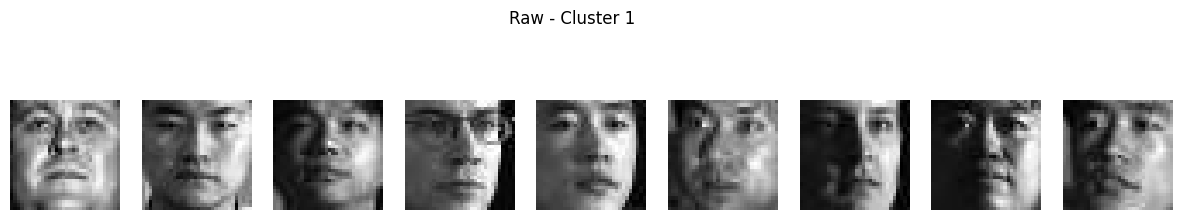

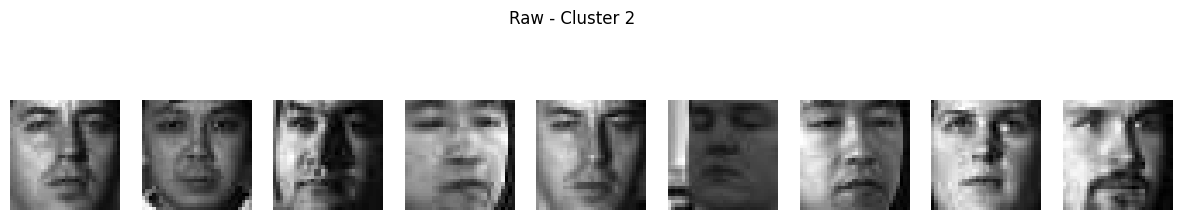

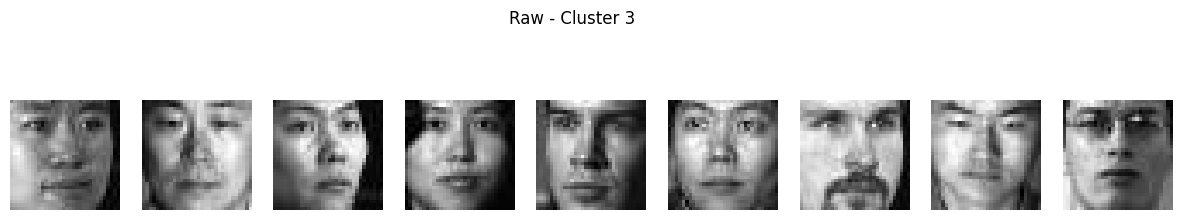

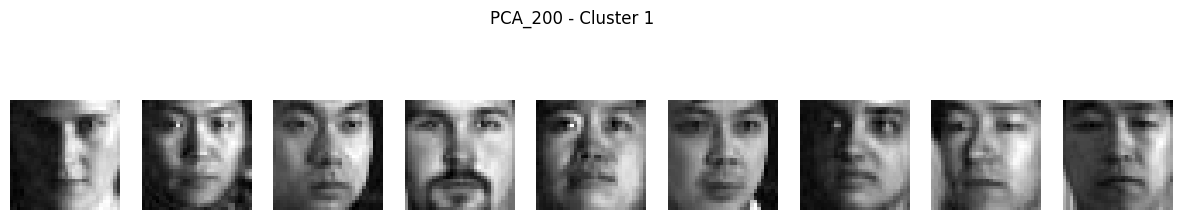

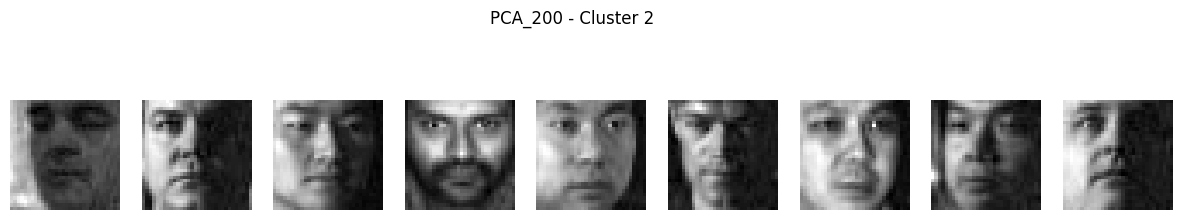

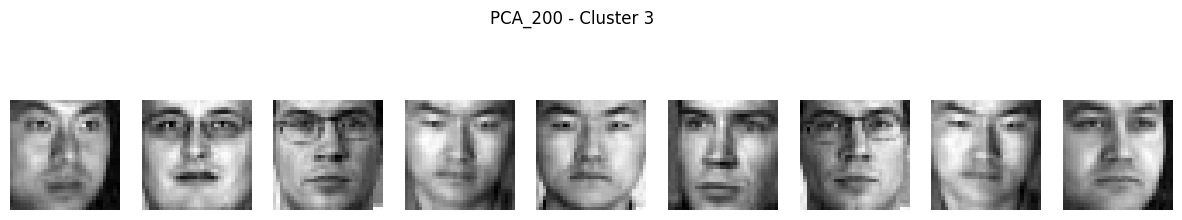

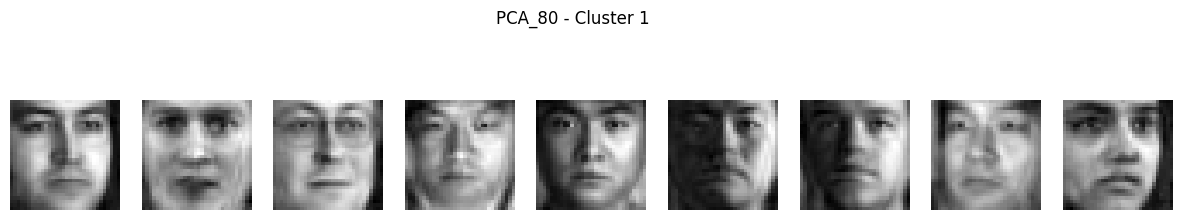

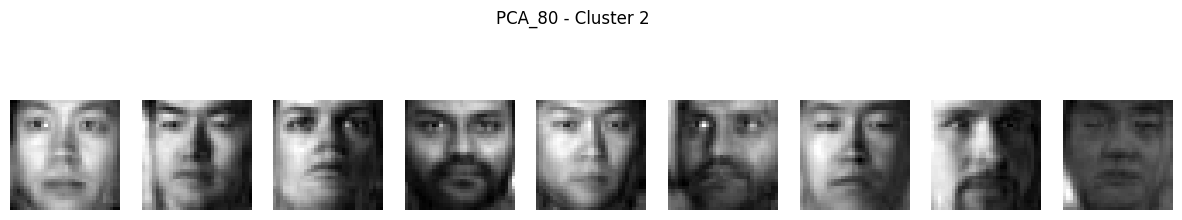

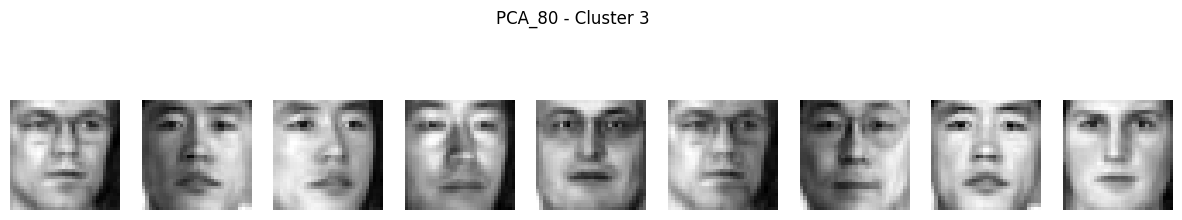

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Function to load and preprocess images from multiple subject folders
def load_images_from_folders(main_folder, img_size=(32, 32)):
    images = []
    labels = []
    subject_id = 0

    # Iterate through the 25 folders for subjects
    for folder_name in os.listdir(main_folder):
        folder_path = os.path.join(main_folder, folder_name)
        if os.path.isdir(folder_path):
            for filename in os.listdir(folder_path):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img_resized = cv2.resize(img, img_size)
                    images.append(img_resized.flatten())
                    labels.append(subject_id)  # Label by subject
            subject_id += 1

    return np.array(images), np.array(labels)

# Function to load selfie images
def load_selfie_images(selfie_folder, img_size=(32, 32)):
    images = []
    labels = []
    for filename in os.listdir(selfie_folder):
        img_path = os.path.join(selfie_folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, img_size)
            images.append(img_resized.flatten())
            labels.append(25)  # Label all selfies as class 25
    return np.array(images), np.array(labels)

# Load images from the 25 subject folders
X_cmu, y_cmu = load_images_from_folders('C:/Users/Administrator/Desktop/EE5907/Qi Ninghan/data')

# Load selfie images
X_selfie, y_selfie = load_selfie_images('C:/Users/Administrator/Desktop/EE5907/Qi Ninghan/selfie')

# Split 25 subjects' dataset into training (70%) and testing (30%)
X_train_cmu, X_test_cmu, y_train_cmu, y_test_cmu = train_test_split(
    X_cmu, y_cmu, test_size=0.3, random_state=42
)

# Split selfie images with stratified sampling (to ensure some selfies are in the test set)
X_train_selfie, X_test_selfie, y_train_selfie, y_test_selfie = train_test_split(
    X_selfie, y_selfie, test_size=0.3, random_state=42
)

# Combine subjects' and selfies' training sets and testing sets separately
X_train = np.vstack((X_train_cmu, X_train_selfie))
y_train = np.hstack((y_train_cmu, y_train_selfie))

X_test = np.vstack((X_test_cmu, X_test_selfie))
y_test = np.hstack((y_test_cmu, y_test_selfie))

# Standardize the training data
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)

# Randomly sample 500 images from the CMU PIE training set and my own photos
N_selfie_train = X_train_selfie.shape[0]
N_sample_cmu = 500 - N_selfie_train

indices_cmu = np.random.choice(X_train_cmu.shape[0], N_sample_cmu, replace=False)
X_sample_cmu = X_train_cmu[indices_cmu]
y_sample_cmu = y_train_cmu[indices_cmu]

X_sample_selfie = X_train_selfie
y_sample_selfie = y_train_selfie

X_sample = np.vstack((X_sample_cmu, X_sample_selfie))
y_sample = np.hstack((y_sample_cmu, y_sample_selfie))

# Standardize the sampled data
X_sample_standardized = scaler.transform(X_sample)

# Prepare datasets for GMM
datasets = {}

# Raw data
datasets['Raw'] = X_train_standardized

# PCA with 200 components
pca_200 = PCA(n_components=200, random_state=42)
X_train_pca_200 = pca_200.fit_transform(X_train_standardized)
datasets['PCA_200'] = X_train_pca_200

# PCA with 80 components
pca_80 = PCA(n_components=80, random_state=42)
X_train_pca_80 = pca_80.fit_transform(X_train_standardized)
datasets['PCA_80'] = X_train_pca_80

# Function to visualize clustering results
def visualize_clusters(X_original, labels, title):
    unique_labels = np.unique(labels)
    num_clusters = len(unique_labels)

    # For each cluster, display a few images
    for cluster in unique_labels:
        cluster_indices = np.where(labels == cluster)[0]
        n_images = min(9, len(cluster_indices))  # Display up to 9 images per cluster
        sample_indices = np.random.choice(cluster_indices, n_images, replace=False)
        
        fig, axes = plt.subplots(1, n_images, figsize=(15, 3))
        for i, idx in enumerate(sample_indices):
            ax = axes[i]
            image = X_original[idx].reshape(32, 32)
            ax.imshow(image, cmap='gray')
            ax.axis('off')
        plt.suptitle(f'{title} - Cluster {cluster+1}')
        plt.show()

# Train GMM and visualize clusters for each dataset
for key, data in datasets.items():
    
    # Train GMM with 3 components
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm.fit(data)
    
    # Predict cluster labels
    cluster_labels = gmm.predict(data)
    
    # For visualization, reconstruct images if using PCA data
    if key == 'Raw':
        X_visual = scaler.inverse_transform(data)
    elif key == 'PCA_200':
        X_visual = scaler.inverse_transform(pca_200.inverse_transform(data))
    elif key == 'PCA_80':
        X_visual = scaler.inverse_transform(pca_80.inverse_transform(data))
    
    # Visualize clusters
    visualize_clusters(X_visual, cluster_labels, key)
